In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd '/content/drive/MyDrive'

/content/drive/MyDrive


In [ ]:
mkdir AI_vs_Real_Image

In [2]:
cd '/content/drive/MyDrive/AI_vs_Real_Image'

/content/drive/MyDrive/AI_vs_Real_Image


In [3]:
!ls

Ai_generated_dataset  mobilenet_model.h5  simple_cnn_model.h5
AI_vs_Real.zip	      real_dataset


In [ ]:
!unzip -q AI_vs_Real.zip

In [5]:
#Import necessary libraries
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    GlobalAveragePooling2D,
    Input
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2

In [6]:
# creating train, test and validation splits
base_output = "/content/final_dataset"

splits = ['train', 'valid', 'test']

classes = ['ai_generated', 'real']

In [7]:
for split in splits:

    for cls in classes:

        os.makedirs(
            os.path.join(base_output, split, cls),
            exist_ok=True
        )


In [8]:
ai_path = "/content/drive/MyDrive/AI_vs_Real_Image/Ai_generated_dataset"

real_path = "/content/drive/MyDrive/AI_vs_Real_Image/real_dataset"

In [9]:
# FUNCTION TO COLLECT IMAGES

def collect_images(folder_path):

    image_paths = []

    for category in os.listdir(folder_path):

        category_path = os.path.join(folder_path, category)

        if os.path.isdir(category_path):

            for image in os.listdir(category_path):

                image_paths.append(
                    os.path.join(category_path, image)
                )

    return image_paths


In [10]:
# COLLECT DATA

ai_images = collect_images(ai_path)

real_images = collect_images(real_path)

print("AI Images:", len(ai_images))

print("Real Images:", len(real_images))

AI Images: 250
Real Images: 745


In [11]:
# ============================================================
# SPLIT FUNCTION
# ============================================================

def split_and_copy(images, class_name):

    random.shuffle(images)

    total = len(images)

    train_end = int(0.7 * total)

    valid_end = int(0.85 * total)

    train_imgs = images[:train_end]

    valid_imgs = images[train_end:valid_end]

    test_imgs = images[valid_end:]

    split_map = {
        'train': train_imgs,
        'valid': valid_imgs,
        'test': test_imgs
    }

    for split_name, split_images in split_map.items():

        for img_path in split_images:

            filename = os.path.basename(img_path)

            destination = os.path.join(
                base_output,
                split_name,
                class_name,
                filename
            )

            shutil.copy(img_path, destination)

# ============================================================
# CREATE SPLITS
# ============================================================

split_and_copy(ai_images, 'ai_generated')

split_and_copy(real_images, 'real')

print("Dataset Split Completed")

Dataset Split Completed


In [12]:
#Dataset Paths
train_dir = "/content/final_dataset/train"
valid_dir = "/content/final_dataset/valid"
test_dir = "/content/final_dataset/test"

In [13]:
IMG_SIZE = 96 #Setting image size as 96
BATCH_SIZE = 8 #Setting batch size of 8

In [14]:
#Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
valid_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [15]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

valid_generator = valid_test_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = valid_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 571 images belonging to 2 classes.
Found 139 images belonging to 2 classes.
Found 143 images belonging to 2 classes.


In [16]:
#Class Names
class_names = list(train_generator.class_indices.keys())
print(class_names)

['ai_generated', 'real']


In [17]:
# COMPUTE CLASS WEIGHTS
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(5.71), 1: np.float64(0.5479846449136276)}


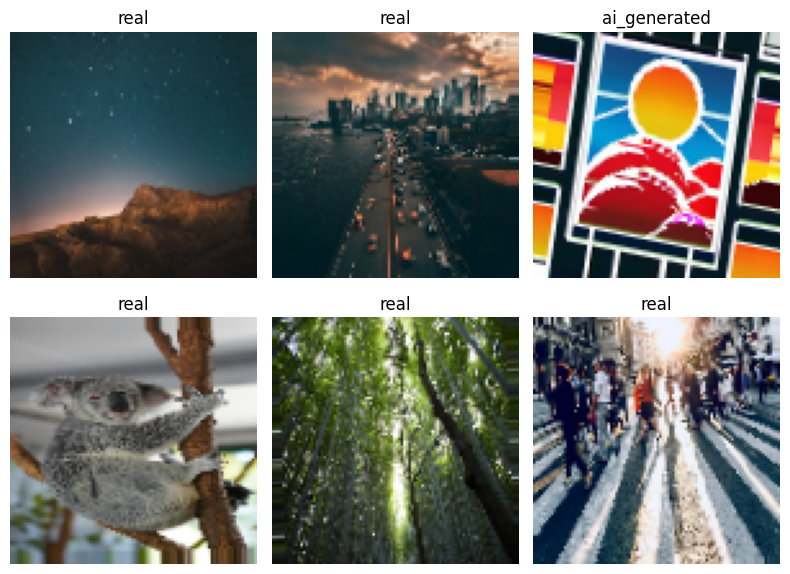

In [21]:
#Sample Images
images, labels = next(train_generator)
plt.figure(figsize=(8,6))
for i in range(min(6, len(images))):

    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[int(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN MODEL FROM SCRATCH

In [22]:
#Building a custom CNN model from scratch
simple_cnn = Sequential([
    Conv2D(
        16,
        (3,3),
        activation='relu',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
simple_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
simple_cnn.summary() #Model summary for custom cnn model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433,313 (1.65 MB)

 Trainable params: 433,313 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
#Defining early stop for models
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [26]:
#Model Training

history_cnn = simple_cnn.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 338ms/step - accuracy: 0.6497 - loss: 0.6999 - val_accuracy: 0.1942 - val_loss: 0.8138
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 290ms/step - accuracy: 0.2189 - loss: 0.6741 - val_accuracy: 0.2086 - val_loss: 0.7512
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 300ms/step - accuracy: 0.4904 - loss: 0.6236 - val_accuracy: 0.6259 - val_loss: 0.6341
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 275ms/step - accuracy: 0.6760 - loss: 0.5865 - val_accuracy: 0.5971 - val_loss: 0.6388
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 192ms/step - accuracy: 0.7408 - loss: 0.4886 - val_accuracy: 0.7050 - val_loss: 0.5423
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 207ms/step - accuracy: 0.7688 - loss: 0.4830 - val_accuracy: 0.5971 - val_loss: 0.6948
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - accuracy: 0.7478 - loss: 0.4647 - val_accuracy: 0.7194 - val_loss: 0.5288
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 189ms/step - accuracy: 0.8179 - loss: 0.4488 - val_accu

In [27]:
#Model Evaluation
cnn_loss, cnn_acc = simple_cnn.evaluate(test_generator)
print("\n==============================")
print("SIMPLE CNN RESULTS")
print("==============================")
print("Test Accuracy:", cnn_acc)
print("Test Loss:", cnn_loss)

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - accuracy: 0.8182 - loss: 0.4034

SIMPLE CNN RESULTS
Test Accuracy: 0.8181818127632141
Test Loss: 0.40340548753738403


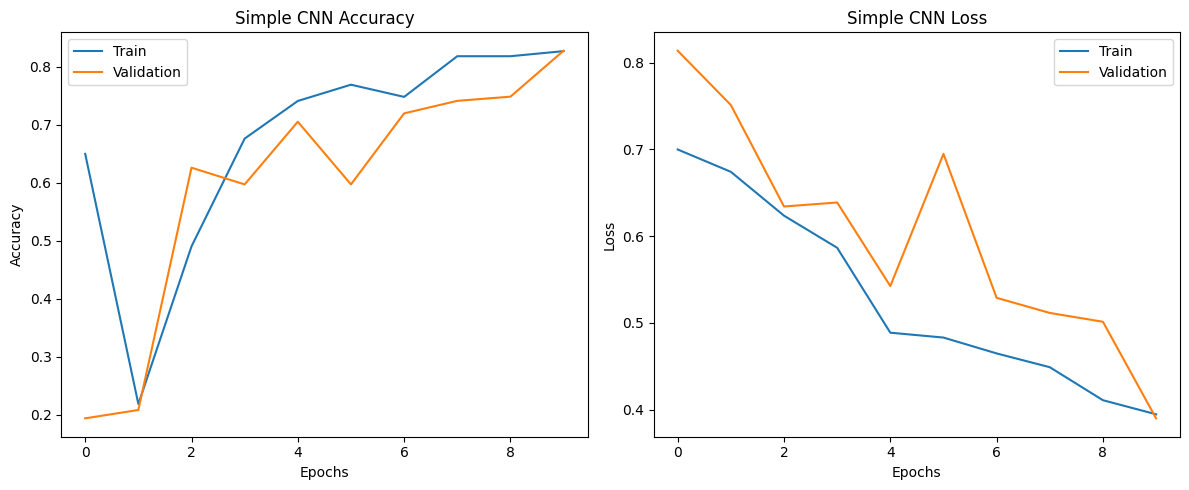

In [28]:
#Accuracy and loss Graph
plt.figure(figsize=(12,5))
# ============================================================
# ACCURACY
# ============================================================
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title("Simple CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])

# ============================================================
# LOSS
# ============================================================
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title("Simple CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.tight_layout()
plt.show()

## MobileNetV2 Model

In [29]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Fine tuning only last layers
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
#Adding extra layers to the pretrained model
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)
mobilenet_model = Model(inputs, outputs)

In [31]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
mobilenet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 1,288,129 (4.91 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [32]:
history_mobile = mobilenet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 91s 716ms/step - accuracy: 0.6375 - loss: 0.8735 - val_accuracy: 0.6403 - val_loss: 0.6666
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 253ms/step - accuracy: 0.6743 - loss: 0.7181 - val_accuracy: 0.6906 - val_loss: 0.6035


In [33]:
#Model Evaluation
mobile_loss, mobile_acc = mobilenet_model.evaluate(test_generator)
print("\n==============================")
print("MOBILENETV2 RESULTS")
print("==============================")
print("Test Accuracy:", mobile_acc)
print("Test Loss:", mobile_loss)

18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 766ms/step - accuracy: 0.6154 - loss: 0.6743

MOBILENETV2 RESULTS
Test Accuracy: 0.6153846383094788
Test Loss: 0.6743082404136658


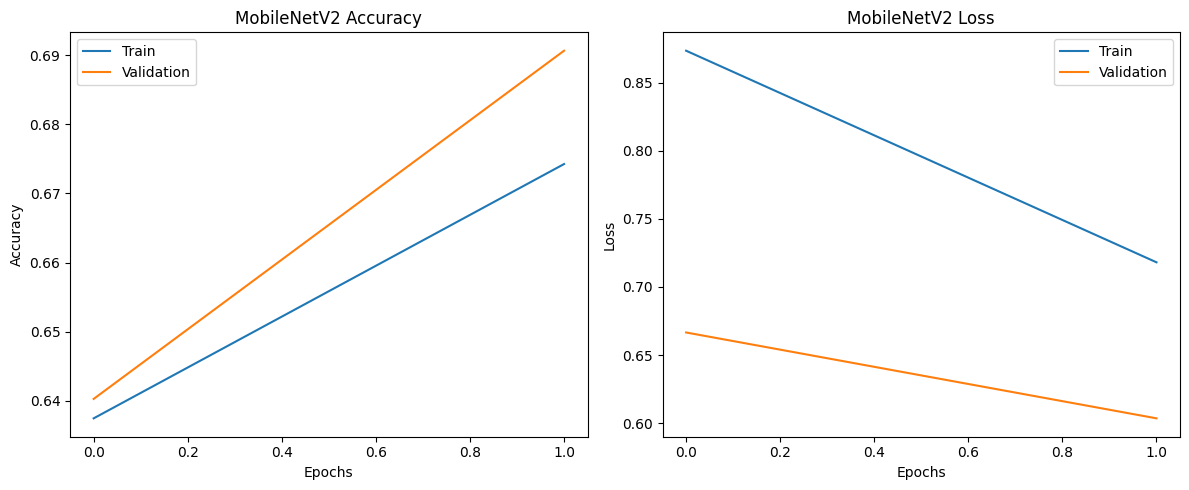

In [34]:
#Accuracy and loss graphs for MobileNet model
plt.figure(figsize=(12,5))
# ============================================================
# ACCURACY
# ============================================================
plt.subplot(1,2,1)
plt.plot(history_mobile.history['accuracy'])
plt.plot(history_mobile.history['val_accuracy'])
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])

# ============================================================
# LOSS
# ============================================================
plt.subplot(1,2,2)
plt.plot(history_mobile.history['loss'])
plt.plot(history_mobile.history['val_loss'])
plt.title("MobileNetV2 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.tight_layout()

plt.show()

In [35]:
#Comparison of accuracy and loss for both models
print("\n==============================")
print("FINAL MODEL COMPARISON")
print("==============================")

print(f"Simple CNN Accuracy  : {cnn_acc:.4f}")
print(f"MobileNet Accuracy   : {mobile_acc:.4f}")
print(f"\nSimple CNN Loss      : {cnn_loss:.4f}")
print(f"MobileNet Loss       : {mobile_loss:.4f}")


FINAL MODEL COMPARISON
Simple CNN Accuracy  : 0.8182
MobileNet Accuracy   : 0.6154

Simple CNN Loss      : 0.4034
MobileNet Loss       : 0.6743


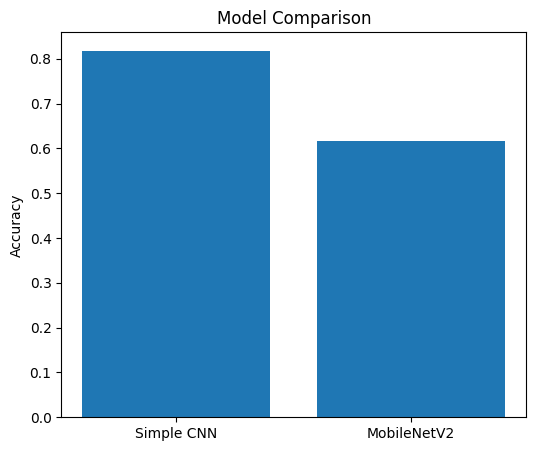

In [38]:
#Bar chart showing comparison
models = ['Simple CNN', 'MobileNetV2']
accuracies = [cnn_acc, mobile_acc]
plt.figure(figsize=(6,5))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step


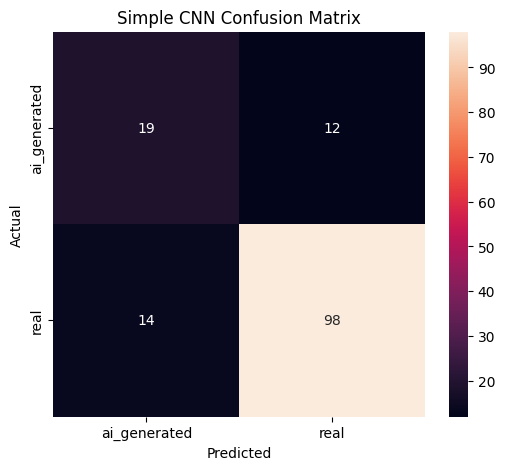

In [39]:
#Confusion matrix for custom cnn model
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = simple_cnn.predict(test_generator)
pred_classes = (predictions > 0.5).astype(int)
true_classes = test_generator.classes
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Simple CNN Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


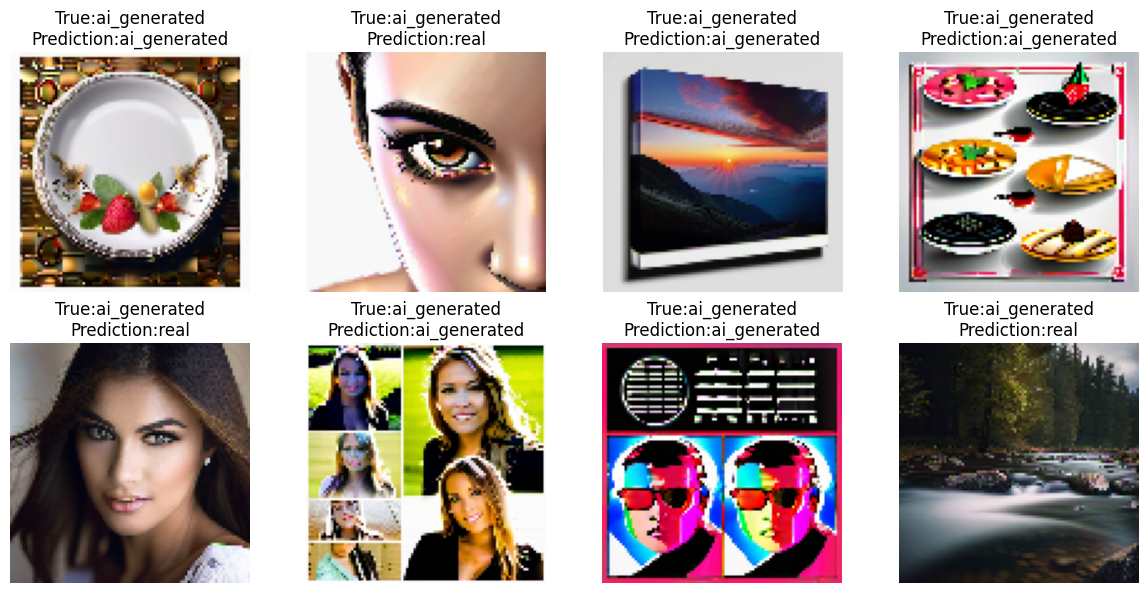

In [41]:
#Random predictions using custom cnn model
images, labels = next(test_generator)
predictions = simple_cnn.predict(images)
plt.figure(figsize=(12,6))

for i in range(min(8, len(images))):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    pred = 1 if predictions[i] > 0.5 else 0
    true_label = class_names[int(labels[i])]
    pred_label = class_names[pred]
    plt.title(f"True:{true_label}\nPrediction:{pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [44]:
#Classification report for custom cnn model
from sklearn.metrics import classification_report
print("Simple CNN Classification Report\n")
print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=class_names
    )
)

Simple CNN Classification Report

              precision    recall  f1-score   support

ai_generated       0.58      0.61      0.59        31
        real       0.89      0.88      0.88       112

    accuracy                           0.82       143
   macro avg       0.73      0.74      0.74       143
weighted avg       0.82      0.82      0.82       143



18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 346ms/step


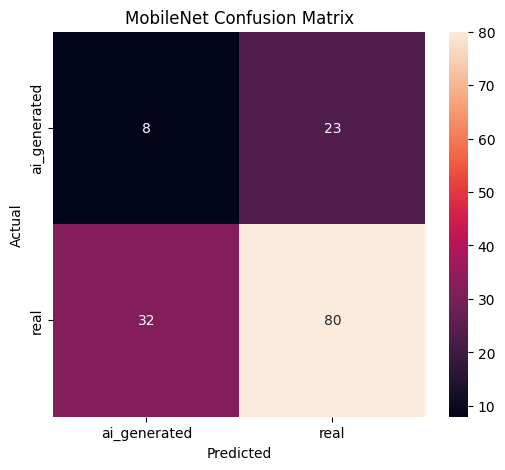

In [45]:
#Confusion Matrix for MobileNet model
predictions = mobilenet_model.predict(test_generator)
pred_classes = (predictions > 0.5).astype(int)
true_classes = test_generator.classes
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNet Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


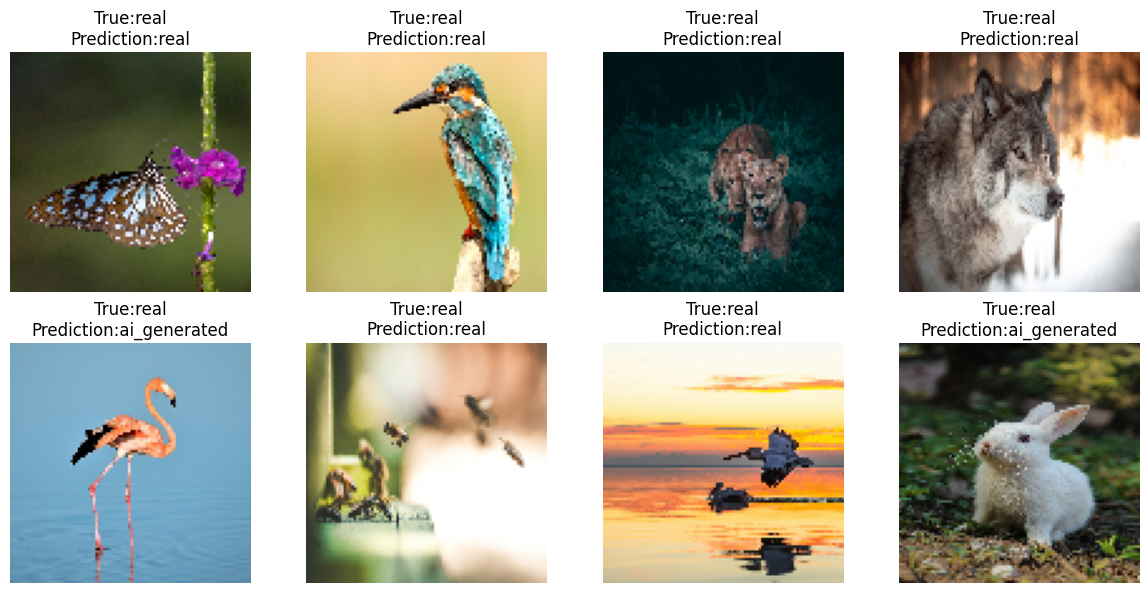

In [48]:
#Random predictions using MobileNet
images, labels = next(test_generator)
predictions = mobilenet_model.predict(images)
plt.figure(figsize=(12,6))
for i in range(min(8, len(images))):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    pred = 1 if predictions[i] > 0.5 else 0
    true_label = class_names[int(labels[i])]
    pred_label = class_names[pred]
    plt.title(f"True:{true_label}\nPrediction:{pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [49]:
#Classification Report for MobileNet
print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

ai_generated       0.20      0.26      0.23        31
        real       0.78      0.71      0.74       112

    accuracy                           0.62       143
   macro avg       0.49      0.49      0.48       143
weighted avg       0.65      0.62      0.63       143



In [50]:
simple_cnn.save(
    "/content/drive/MyDrive/AI_vs_Real_Image/simple_cnn_model.h5"
)

In [51]:
mobilenet_model.save(
    "/content/drive/MyDrive/AI_vs_Real_Image/mobilenet_model.h5"
)

For this small and moderately imbalanced AI-vs-real image dataset, the lightweight custom CNN generalized better than the pretrained MobileNetV2 architecture. Despite applying class weighting and EarlyStopping, MobileNetV2 struggled to adapt effectively, while the custom CNN learned more task-specific features and maintained better class balance.